### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "PSO"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "DistilGPT2"
DATASET_NAME = "Install"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Python Version Checking

In [ ]:
# ============================================================
# Python Environment Verification
# ============================================================

# Display the current Python version to ensure compatibility
# with the required libraries and experimental setup

!python --version

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Python 3.10.20


### GPU Checking

In [ ]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Thu Mar 19 23:09:58 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   31C    P8             12W /  300W |   48196MiB /  49140MiB |      4%      Default |
|           

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import time
import warnings

warnings.filterwarnings("ignore")

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualization
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
    cohen_kappa_score,
)
from scipy.sparse import hstack, csr_matrix
from sklearn.linear_model import LogisticRegression
# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ============================================================
# Transformers
# ============================================================
from transformers import (
    BertTokenizer,
    TFBertModel,
    GPT2Tokenizer,
    TFGPT2Model,
)


import joblib

### GPU Status Checking

In [ ]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [ ]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")

    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")

    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [3]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Dependency_Count,Total_Dependencies,Direct_Dependency_Count,Direct_Dependencies,Indirect_Dependency_Count,Indirect_Dependencies,Level
0,10Cent10-999.0.4.tar.gz,0,NaN,0,NaN,0,NaN,1
1,10Cent11-999.0.4.tar.gz,0,NaN,0,NaN,0,NaN,1
2,11Cent-999.0.0.tar.gz,0,NaN,0,NaN,0,NaN,1
3,11Cent-999.0.1.tar.gz,0,NaN,0,NaN,0,NaN,1
4,11Cent-999.0.2.tar.gz,0,NaN,0,NaN,0,NaN,1


### Clear Backend Session

In [4]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Feature Processing

In [10]:
# ============================================================
# Metadata Preprocessing and Feature Construction
# ============================================================

# Remove non-informative identifier column if present
if 'Package_Name' in data.columns:
    data = data.drop(columns=['Package_Name'])

# ------------------------------------------------------------
# Step 1: Construct a unified categorical text representation
# ------------------------------------------------------------

# Identify categorical feature columns, excluding the target label
categorical_columns = [
    col for col in data.columns
    if data[col].dtype == 'object' and col != 'Level'
]

# Concatenate all categorical attributes into a single text feature
data['Combined_Categorical'] = (
    data[categorical_columns]
    .fillna('')
    .astype(str)
    .agg(' '.join, axis=1)
)

# Vectorize the combined categorical feature using bi-grams and tri-grams
vectorizer = CountVectorizer(ngram_range=(2, 3))
categorical_ngram_features = vectorizer.fit_transform(data['Combined_Categorical'])

# ------------------------------------------------------------
# Step 2: Extract and prepare numerical features
# ------------------------------------------------------------

# Select only valid numerical columns, excluding the target label
numerical_columns = [
    col for col in data.columns
    if pd.to_numeric(data[col], errors='coerce').notnull().all() and col != 'Level'
]

# Convert numerical features to float and handle missing values
numerical_features = data[numerical_columns].fillna(0).astype(float)

# Transform numerical features into sparse representation
numerical_features_sparse = csr_matrix(numerical_features.values)

# ------------------------------------------------------------
# Step 3: Combine categorical and numerical representations
# ------------------------------------------------------------

# Concatenate sparse numerical features with categorical n-gram features
X = hstack([numerical_features_sparse, categorical_ngram_features])

# ------------------------------------------------------------
# Step 4: Feature scaling
# ------------------------------------------------------------

# Standardize the combined sparse feature matrix
# Note: with_mean=False is required for sparse matrices
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

### Selected Features

In [11]:
selected_features = ['Total_Dependencies', 'Direct_Dependency_Count', 'Indirect_Dependencies']

### Data Preprocessing

In [12]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 3)
Validation set shape   : (2141, 3)
Test set shape         : (2141, 3)


### Setup OUTPUT_DIR

In [13]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Install_PSO_Attention_DistilGPT2'

### Model

In [14]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# =========================================================
# Detect categorical and numeric columns
# =========================================================

categorical_cols = X_train.select_dtypes(include=['object']).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns


# =========================================================
# Convert each row into a single text string
# =========================================================

def row_to_text(row):

    text = " ".join([f"{col}:{row[col]}" for col in categorical_cols])

    return text

X_train_text = X_train.apply(row_to_text, axis=1)
X_val_text   = X_val.apply(row_to_text, axis=1)
X_test_text  = X_test.apply(row_to_text, axis=1)


# =========================================================
# Load DistilGPT2 tokenizer and model
# =========================================================

MODEL = "distilgpt2"
tokenizer = GPT2Tokenizer.from_pretrained(MODEL)
tokenizer.pad_token = tokenizer.eos_token
gpt_model = TFGPT2Model.from_pretrained(MODEL)


# =========================================================
# Tokenization
# =========================================================

MAX_LEN = 64

def encode_texts(texts):

    enc = tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
        return_tensors="tf"
    )

    return enc

train_enc = encode_texts(X_train_text)
val_enc   = encode_texts(X_val_text)
test_enc  = encode_texts(X_test_text)


# =========================================================
# Process numeric features
# =========================================================

if len(numeric_cols) > 0:

    scaler = StandardScaler()

    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])

else:

    X_train_num = np.empty((len(X_train), 0))
    X_val_num   = np.empty((len(X_val), 0))
    X_test_num  = np.empty((len(X_test), 0))

# Convert to float32
X_train_num = X_train_num.astype(np.float32)
X_val_num   = X_val_num.astype(np.float32)
X_test_num  = X_test_num.astype(np.float32)


# =========================================================
# Labels
# =========================================================

y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# =========================================================
# Callbacks
# =========================================================

checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True
)


# =========================================================
# Build DistilGPT2 Hybrid Model
# =========================================================

input_ids = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)
attention_mask = tf.keras.Input(shape=(MAX_LEN,), dtype=tf.int32)

# Transformer output
gpt_outputs = gpt_model(
    input_ids,
    attention_mask=attention_mask
)

# Use last token representation
text_features = gpt_outputs.last_hidden_state[:, -1, :]

# Numeric input
num_input = tf.keras.Input(shape=(X_train_num.shape[1],))
num_branch = layers.Dense(64, activation="relu")(num_input)
num_branch = layers.Dropout(0.2)(num_branch)

# Combine text + numeric
x = layers.Concatenate()([text_features, num_branch])

# Classification head
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(
    inputs=[input_ids, attention_mask, num_input],
    outputs=output
)

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

All model checkpoint layers were used when initializing TFGPT2Model.

All the layers of TFGPT2Model were initialized from the model checkpoint at distilgpt2.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFGPT2Model for predictions without further training.


Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_4 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_5 (InputLayer)           [(None, 64)]         0           []                               
                                                                                                  
 input_6 (InputLayer)           [(None, 1)]          0           []                               
                                                                                                  
 tfgpt2_model_1 (TFGPT2Model)   TFBaseModelOutputWi  81912576    ['input_4[0][0]',                
                                thPastAndCrossAtten               'input_5[0][0]']          

### Compime the Model

In [15]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(

    [
        train_enc["input_ids"],
        train_enc["attention_mask"],
        X_train_num
    ],

    y_train,

    validation_data=(

        [
            val_enc["input_ids"],
            val_enc["attention_mask"],
            X_val_num
        ],

        y_val
    ),

    epochs=200,
    batch_size=16,

    callbacks=[
        checkpoint_cb,
        reduce_lr_cb,
        early_stop_cb
    ]

)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
624/625 [============================>.] - ETA: 0s - loss: 0.5816 - accuracy: 0.6473
Epoch 1: val_accuracy improved from -inf to 0.67959, saving model to Evaluation_Outputs_Install_PSO_Attention_DistilGPT2\Evaluation_Outputs_Install_PSO_Attention_DistilGPT2.h5
625/625 [==============================] - 45s 57ms/step - loss: 0.5818 - accuracy: 0.6472 - val_loss: 0.5215 - val_accuracy: 0.6796 - lr: 1.0000e-04
Epoch 2/200
624/625 [============================>.] - ETA: 0s - loss: 0.4486 - accuracy: 0.7140
Epoch 2: val_accuracy improved from 0.67959 to 0.73844, saving model to Evaluation_Outputs_Install_PSO_Attention_DistilGPT2\Evaluation_Outputs_Install_PSO_Attention_DistilGPT2.h5
625/625 [==============================] - 34s 54ms/step - loss: 0.4487 - accuracy: 0.7141 - val_loss: 0.3961 - val_accuracy: 0.7384 - lr: 1.0000e-04
Epoch 3/200
625/625 [==============================] - ETA: 0s - loss: 0.3871 - accuracy: 0.7380
Epoch 3: val_accuracy improved from 0.73844 to 0.74498

625/625 [==============================] - ETA: 0s - loss: 0.3566 - accuracy: 0.7421
Epoch 26: val_accuracy did not improve from 0.74778
625/625 [==============================] - 34s 54ms/step - loss: 0.3566 - accuracy: 0.7421 - val_loss: 0.3558 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 27/200
624/625 [============================>.] - ETA: 0s - loss: 0.3565 - accuracy: 0.7469
Epoch 27: val_accuracy did not improve from 0.74778
625/625 [==============================] - 31s 50ms/step - loss: 0.3565 - accuracy: 0.7468 - val_loss: 0.3559 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 28/200
625/625 [==============================] - ETA: 0s - loss: 0.3557 - accuracy: 0.7478
Epoch 28: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3557 - accuracy: 0.7478 - val_loss: 0.3559 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 29/200
625/625 [==============================] - ETA: 0s - loss: 0.3560 - accuracy: 0.7419
Epoch 29: val_a

625/625 [==============================] - 29s 46ms/step - loss: 0.3555 - accuracy: 0.7502 - val_loss: 0.3557 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 54/200
625/625 [==============================] - ETA: 0s - loss: 0.3557 - accuracy: 0.7492
Epoch 54: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3557 - accuracy: 0.7492 - val_loss: 0.3558 - val_accuracy: 0.7389 - lr: 1.0000e-04
Epoch 55/200
625/625 [==============================] - ETA: 0s - loss: 0.3553 - accuracy: 0.7463
Epoch 55: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3553 - accuracy: 0.7463 - val_loss: 0.3558 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 56/200
625/625 [==============================] - ETA: 0s - loss: 0.3556 - accuracy: 0.7497
Epoch 56: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3556 - accuracy: 0.7497 - val_los

Epoch 81/200
625/625 [==============================] - ETA: 0s - loss: 0.3551 - accuracy: 0.7509
Epoch 81: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3551 - accuracy: 0.7509 - val_loss: 0.3558 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 82/200
625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7498
Epoch 82: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 47ms/step - loss: 0.3550 - accuracy: 0.7498 - val_loss: 0.3557 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 83/200
625/625 [==============================] - ETA: 0s - loss: 0.3552 - accuracy: 0.7510
Epoch 83: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3552 - accuracy: 0.7510 - val_loss: 0.3557 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 84/200
625/625 [==============================] - ETA: 0s - loss: 0.3552 - accuracy: 0.7489
Ep

625/625 [==============================] - ETA: 0s - loss: 0.3551 - accuracy: 0.7503
Epoch 108: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3551 - accuracy: 0.7503 - val_loss: 0.3560 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 109/200
625/625 [==============================] - ETA: 0s - loss: 0.3549 - accuracy: 0.7525
Epoch 109: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3549 - accuracy: 0.7525 - val_loss: 0.3562 - val_accuracy: 0.7473 - lr: 1.0000e-04
Epoch 110/200
625/625 [==============================] - ETA: 0s - loss: 0.3555 - accuracy: 0.7490
Epoch 110: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3555 - accuracy: 0.7490 - val_loss: 0.3558 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 111/200
625/625 [==============================] - ETA: 0s - loss: 0.3551 - accuracy: 0.7513
Epoch 111

625/625 [==============================] - ETA: 0s - loss: 0.3548 - accuracy: 0.7518
Epoch 135: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3548 - accuracy: 0.7518 - val_loss: 0.3576 - val_accuracy: 0.7384 - lr: 1.0000e-04
Epoch 136/200
624/625 [============================>.] - ETA: 0s - loss: 0.3551 - accuracy: 0.7472
Epoch 136: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3550 - accuracy: 0.7472 - val_loss: 0.3565 - val_accuracy: 0.7473 - lr: 1.0000e-04
Epoch 137/200
625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7512
Epoch 137: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 47ms/step - loss: 0.3550 - accuracy: 0.7512 - val_loss: 0.3559 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 138/200
625/625 [==============================] - ETA: 0s - loss: 0.3549 - accuracy: 0.7502
Epoch 138

625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7509
Epoch 162: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3550 - accuracy: 0.7509 - val_loss: 0.3557 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 163/200
625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7509
Epoch 163: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3550 - accuracy: 0.7509 - val_loss: 0.3558 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 164/200
625/625 [==============================] - ETA: 0s - loss: 0.3549 - accuracy: 0.7518
Epoch 164: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3549 - accuracy: 0.7518 - val_loss: 0.3588 - val_accuracy: 0.7473 - lr: 1.0000e-04
Epoch 165/200
625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7518
Epoch 165

625/625 [==============================] - ETA: 0s - loss: 0.3549 - accuracy: 0.7513
Epoch 189: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3549 - accuracy: 0.7513 - val_loss: 0.3558 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 190/200
625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7513
Epoch 190: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3550 - accuracy: 0.7513 - val_loss: 0.3557 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 191/200
625/625 [==============================] - ETA: 0s - loss: 0.3549 - accuracy: 0.7510
Epoch 191: val_accuracy did not improve from 0.74778
625/625 [==============================] - 29s 46ms/step - loss: 0.3549 - accuracy: 0.7510 - val_loss: 0.3557 - val_accuracy: 0.7478 - lr: 1.0000e-04
Epoch 192/200
625/625 [==============================] - ETA: 0s - loss: 0.3550 - accuracy: 0.7509
Epoch 192

### Clear Backend Session

In [16]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [17]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(
    [
        val_enc["input_ids"],
        val_enc["attention_mask"],
        X_val_num
    ],
    y_val,
    verbose=0
)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(
    [
        test_enc["input_ids"],
        test_enc["attention_mask"],
        X_test_num
    ],
    y_test,
    verbose=0
)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 5843.12 seconds
Validation Time: 1.55 seconds
Testing Time: 1.06 seconds

Validation Accuracy: 0.7478
Test Accuracy: 0.7571


### Save Training Log

In [18]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Install_PSO_Attention_DistilGPT2\training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.581826,0.647212,0.521541,0.679589,0.0001
1,2,0.448675,0.714086,0.396065,0.738440,0.0001
2,3,0.387136,0.738012,0.364702,0.744979,0.0001
3,4,0.368087,0.741315,0.361022,0.745446,0.0001
4,5,0.361867,0.742016,0.362955,0.745446,0.0001


### Trainig and Validation Plot

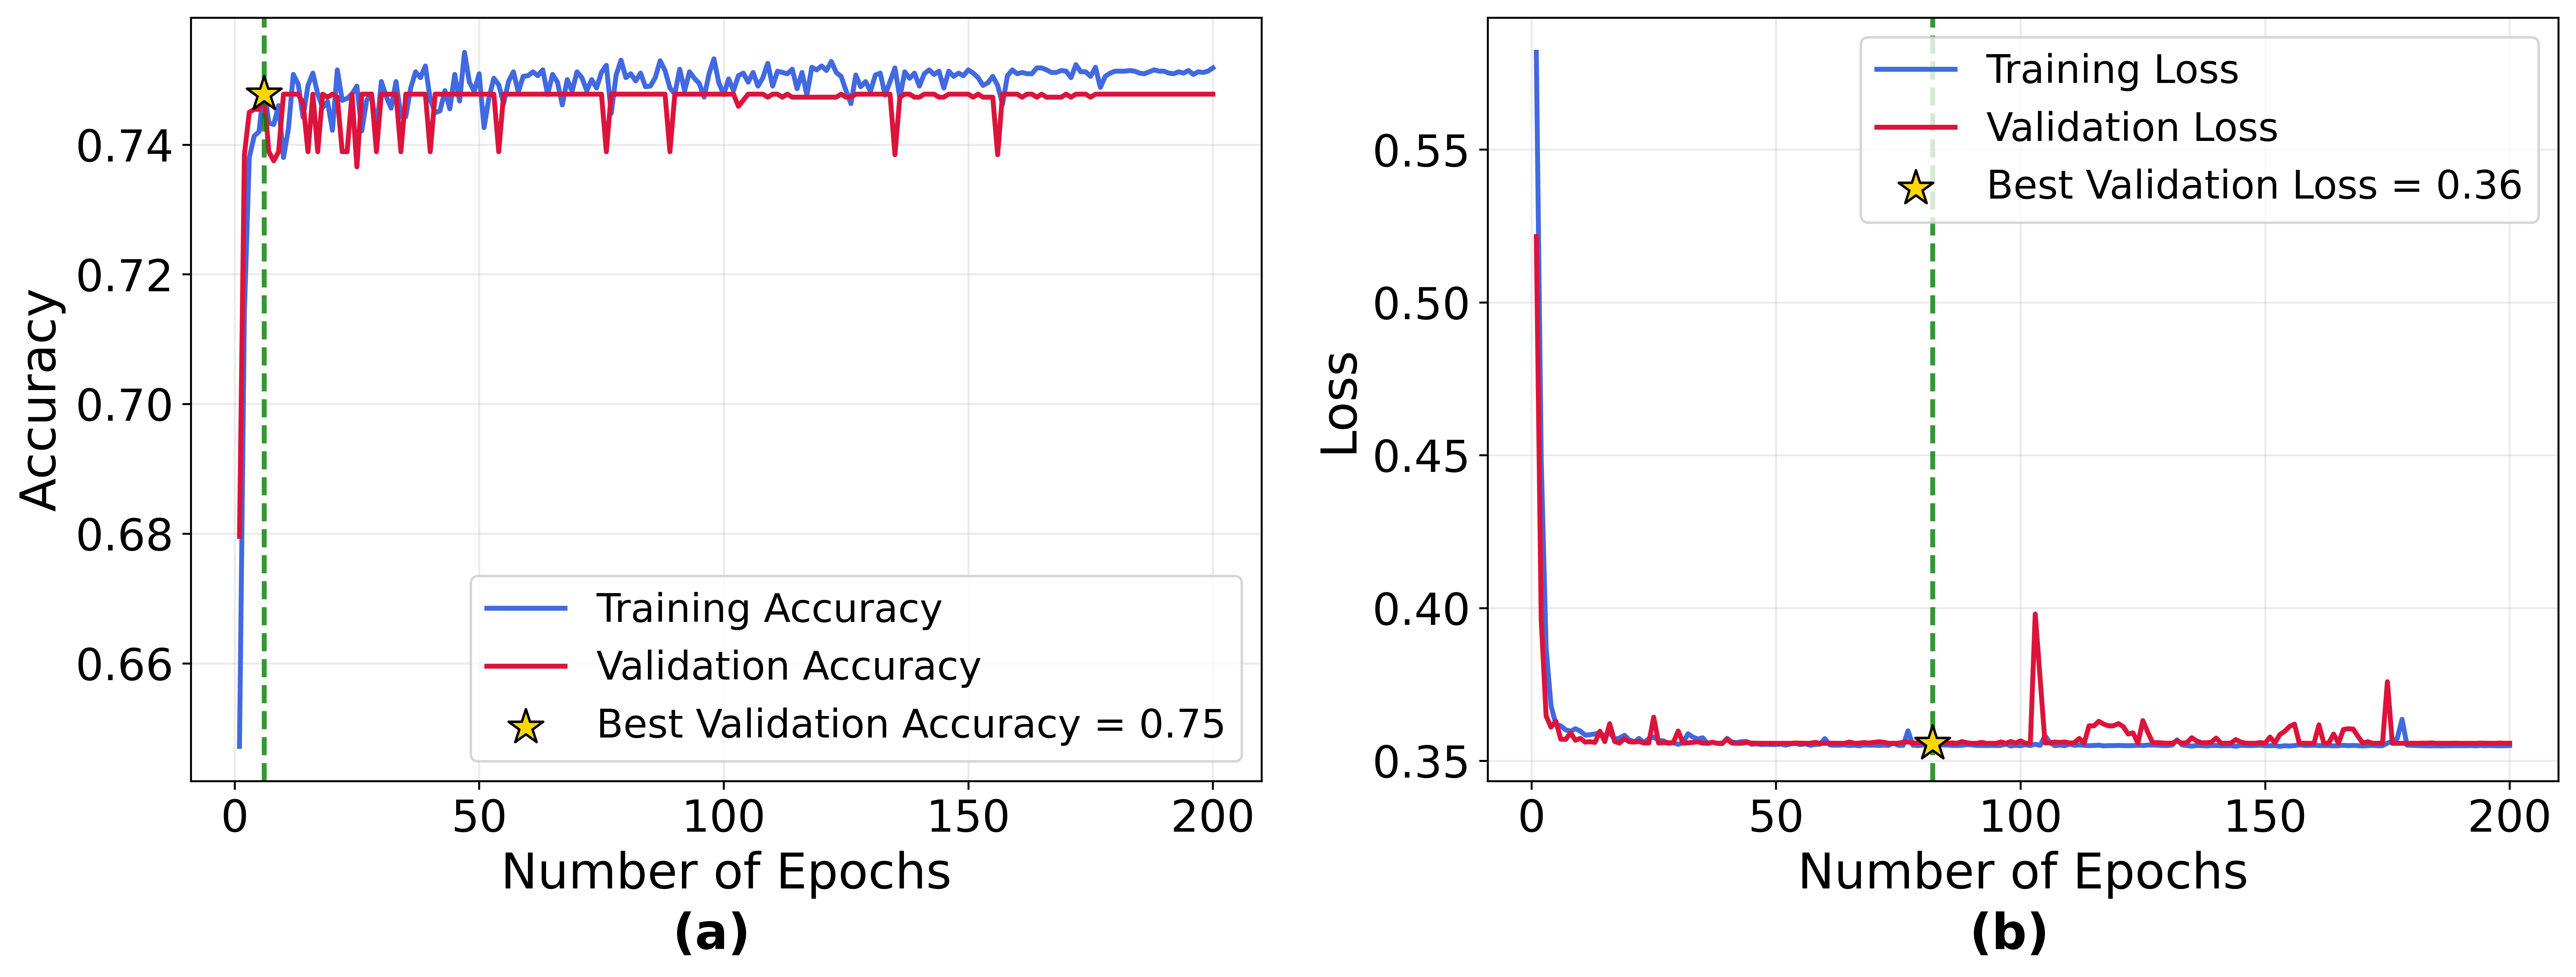

In [19]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")

# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")

# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.751326
Precision : 0.667603
Recall    : 1.000000
F1-score  : 0.800674
ROC AUC   : 0.868951
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   1.000000  0.503200  0.669505      5000
         1.0   0.667603  1.000000  0.800674      4989

    accuracy                       0.751326      9989
   macro avg   0.833802  0.751600  0.735090      9989
weighted avg   0.833985  0.751326  0.735017      9989



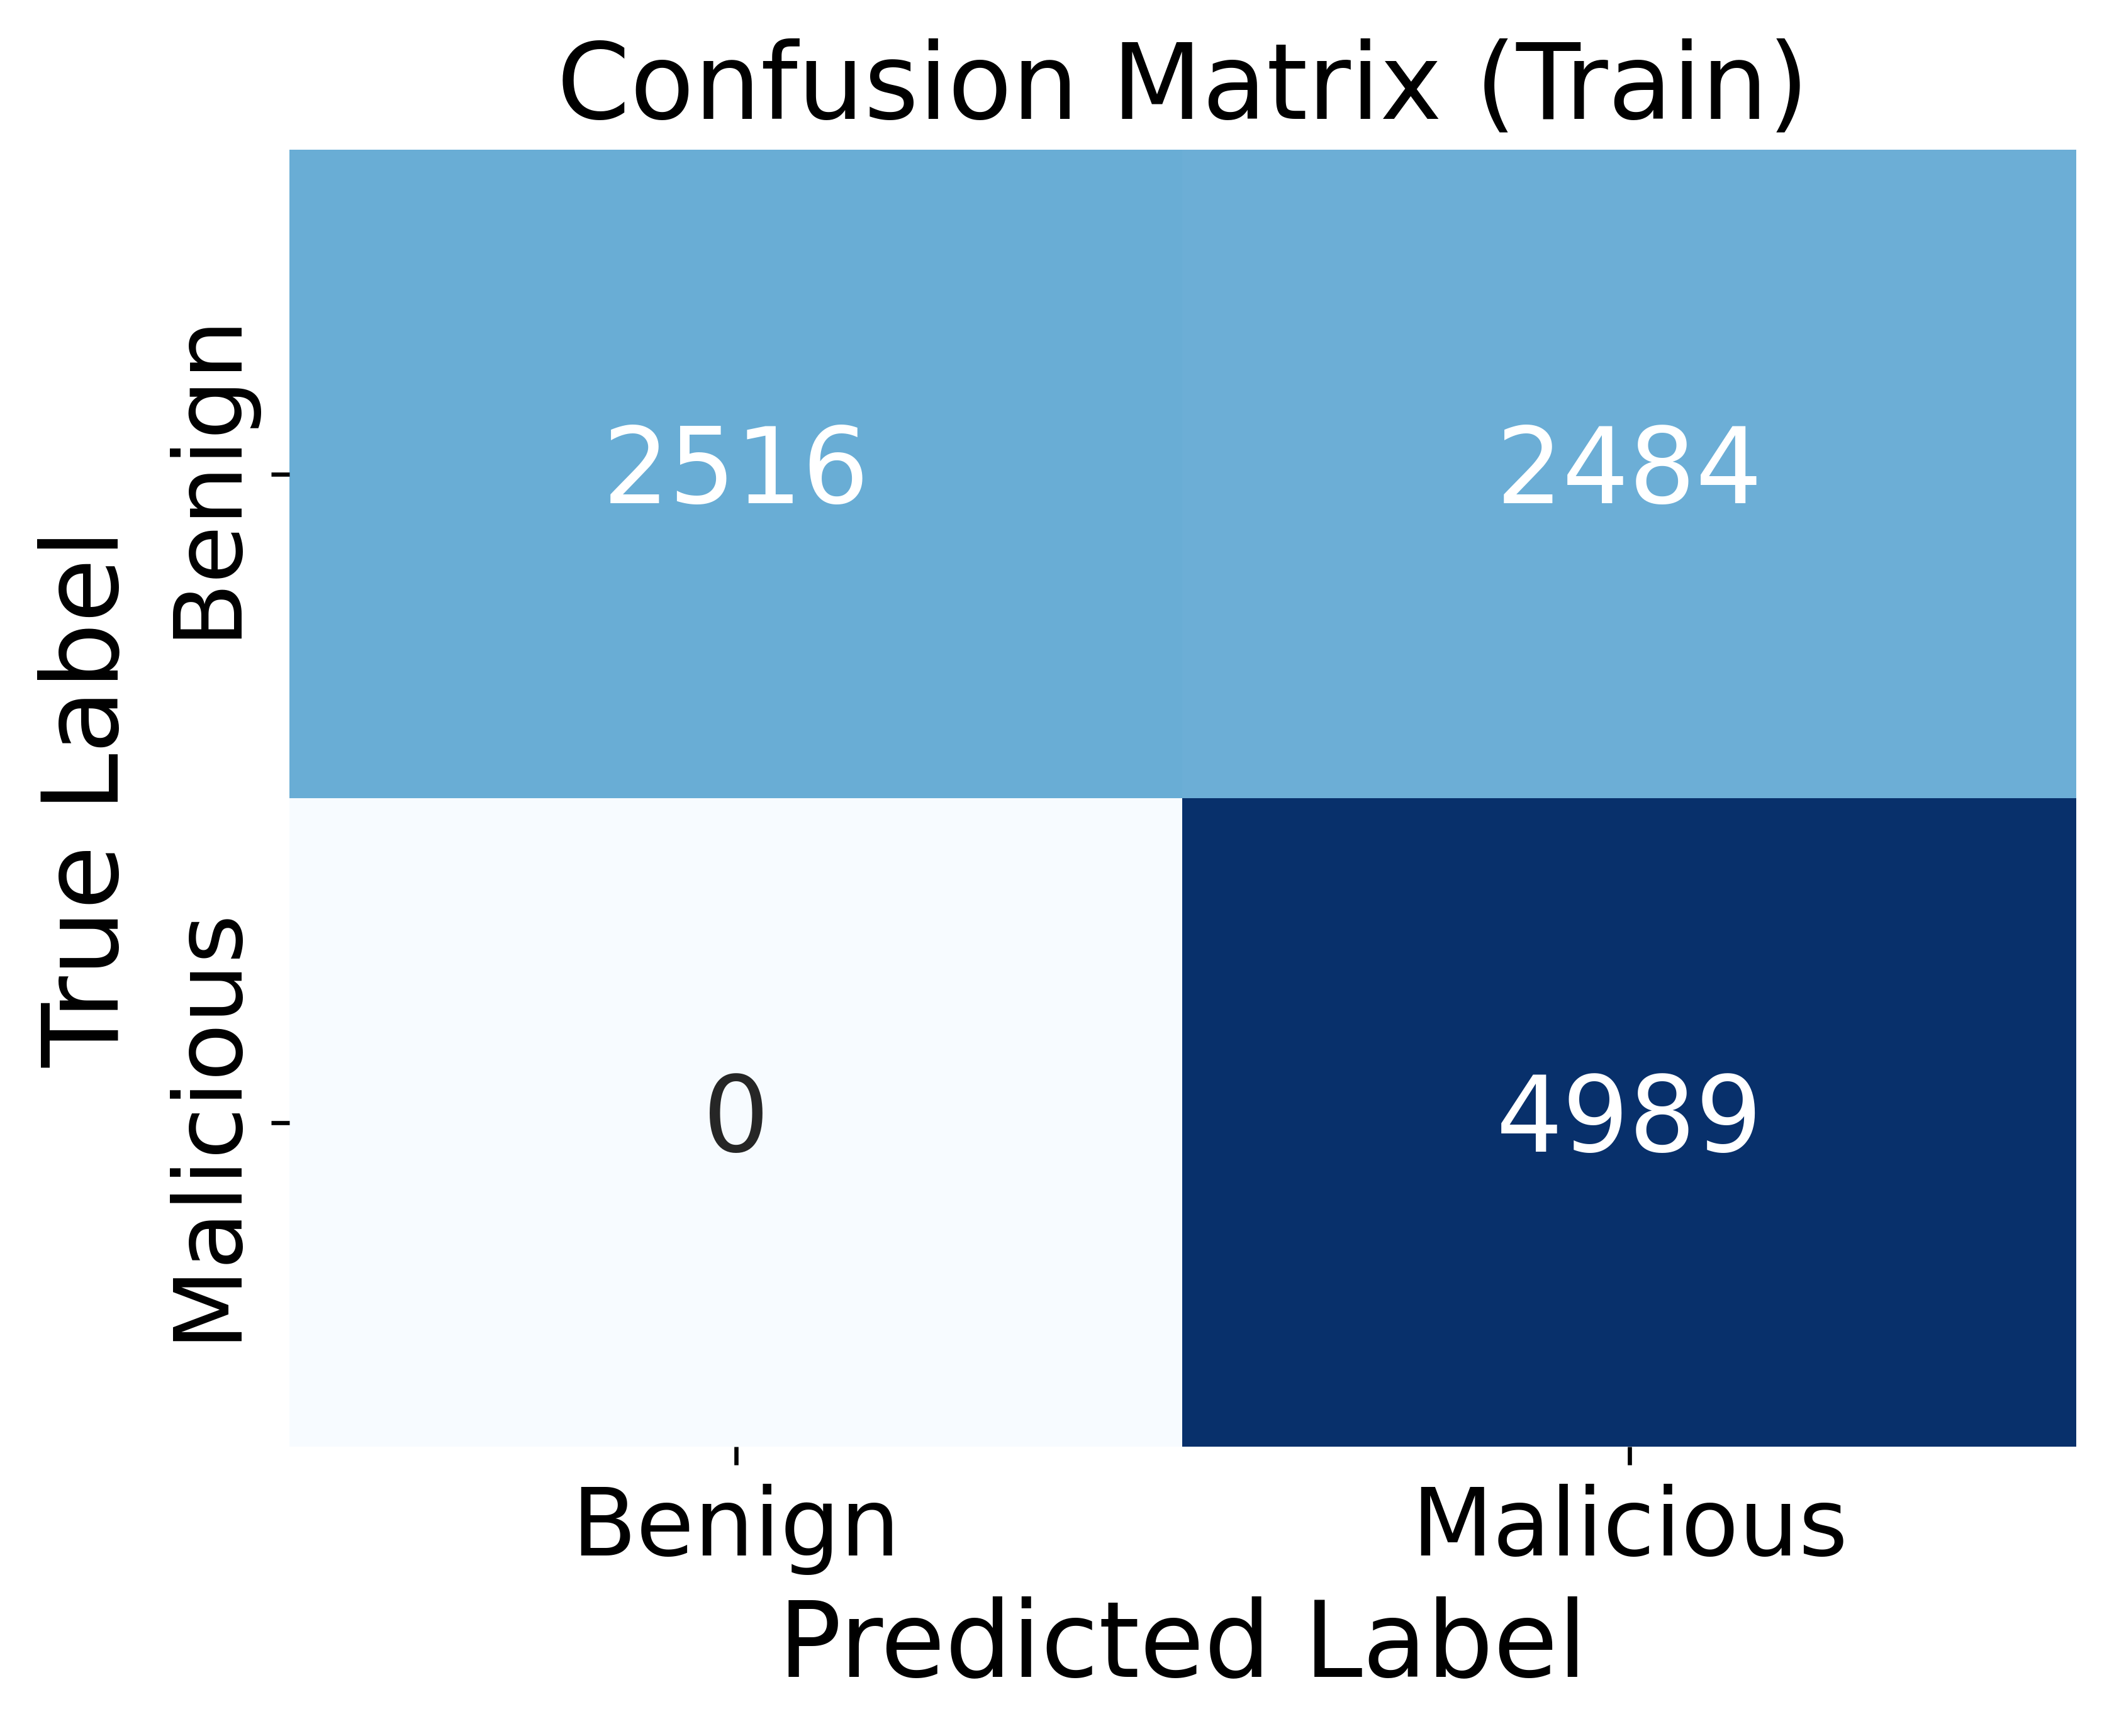

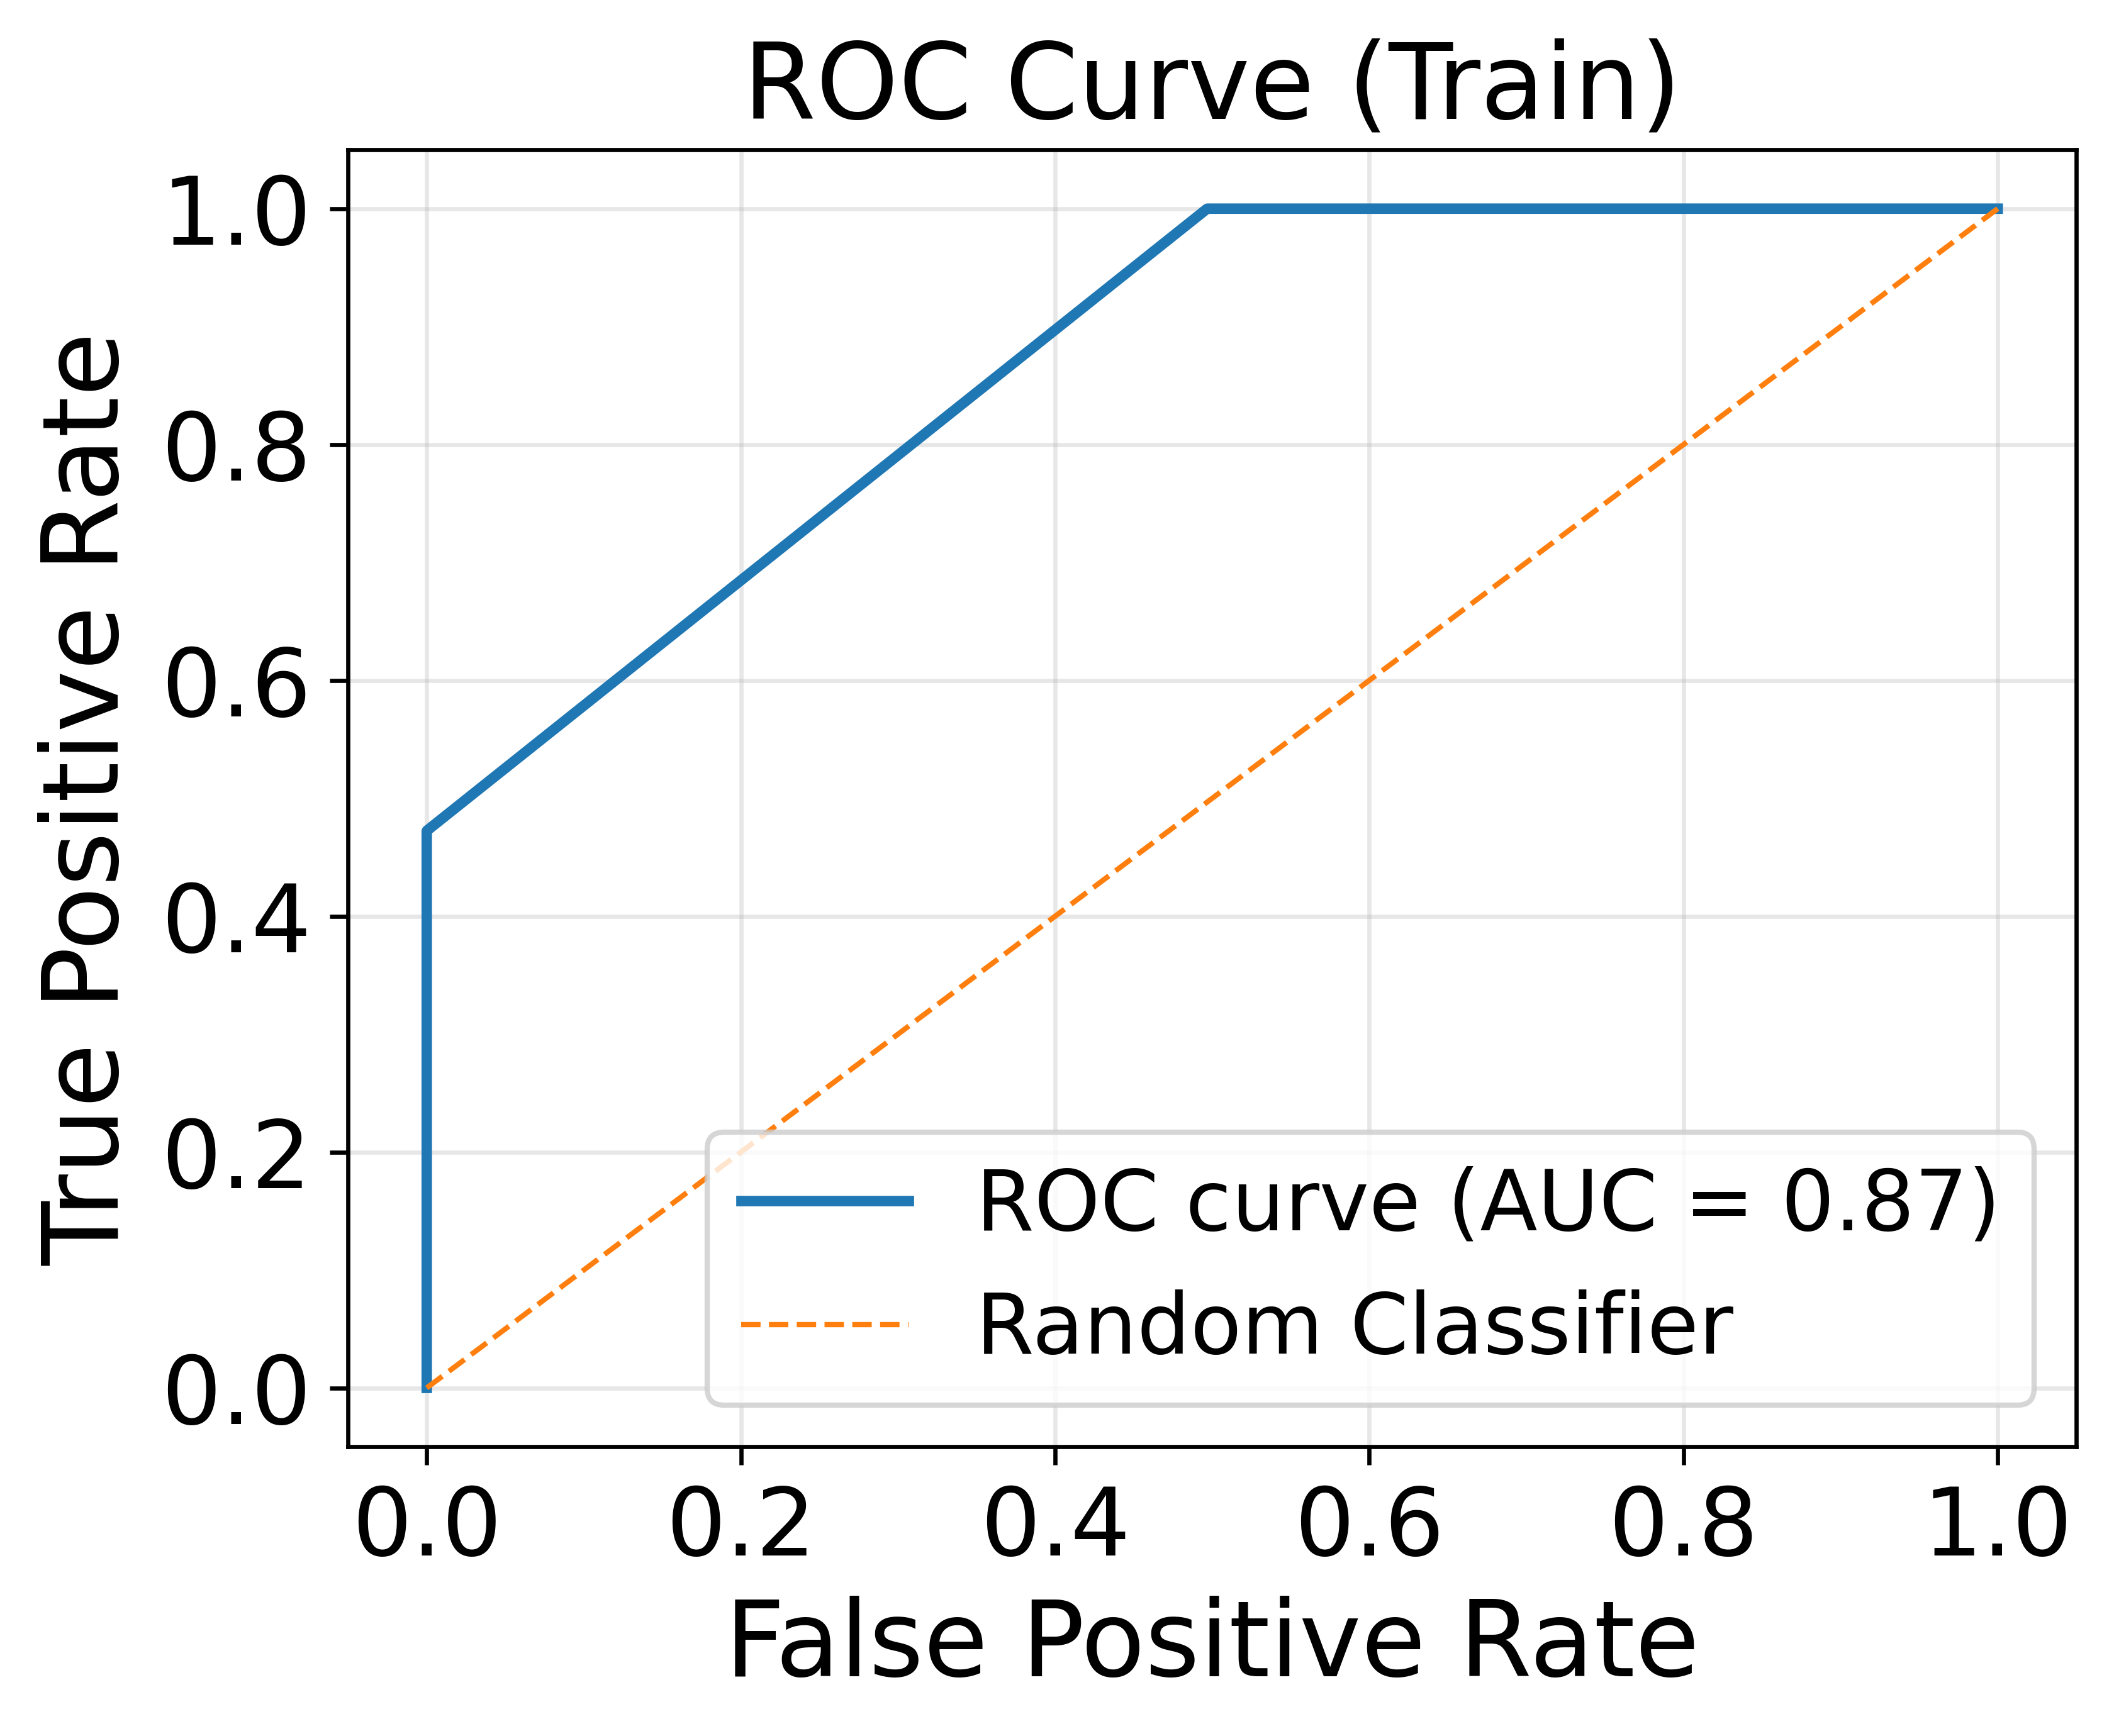


Evaluation Results: Validation
Accuracy  : 0.747781
Precision : 0.664388
Recall    : 1.000000
F1-score  : 0.798357
ROC AUC   : 0.868295
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   1.000000  0.496269  0.663342      1072
         1.0   0.664388  1.000000  0.798357      1069

    accuracy                       0.747781      2141
   macro avg   0.832194  0.748134  0.730849      2141
weighted avg   0.832429  0.747781  0.730755      2141



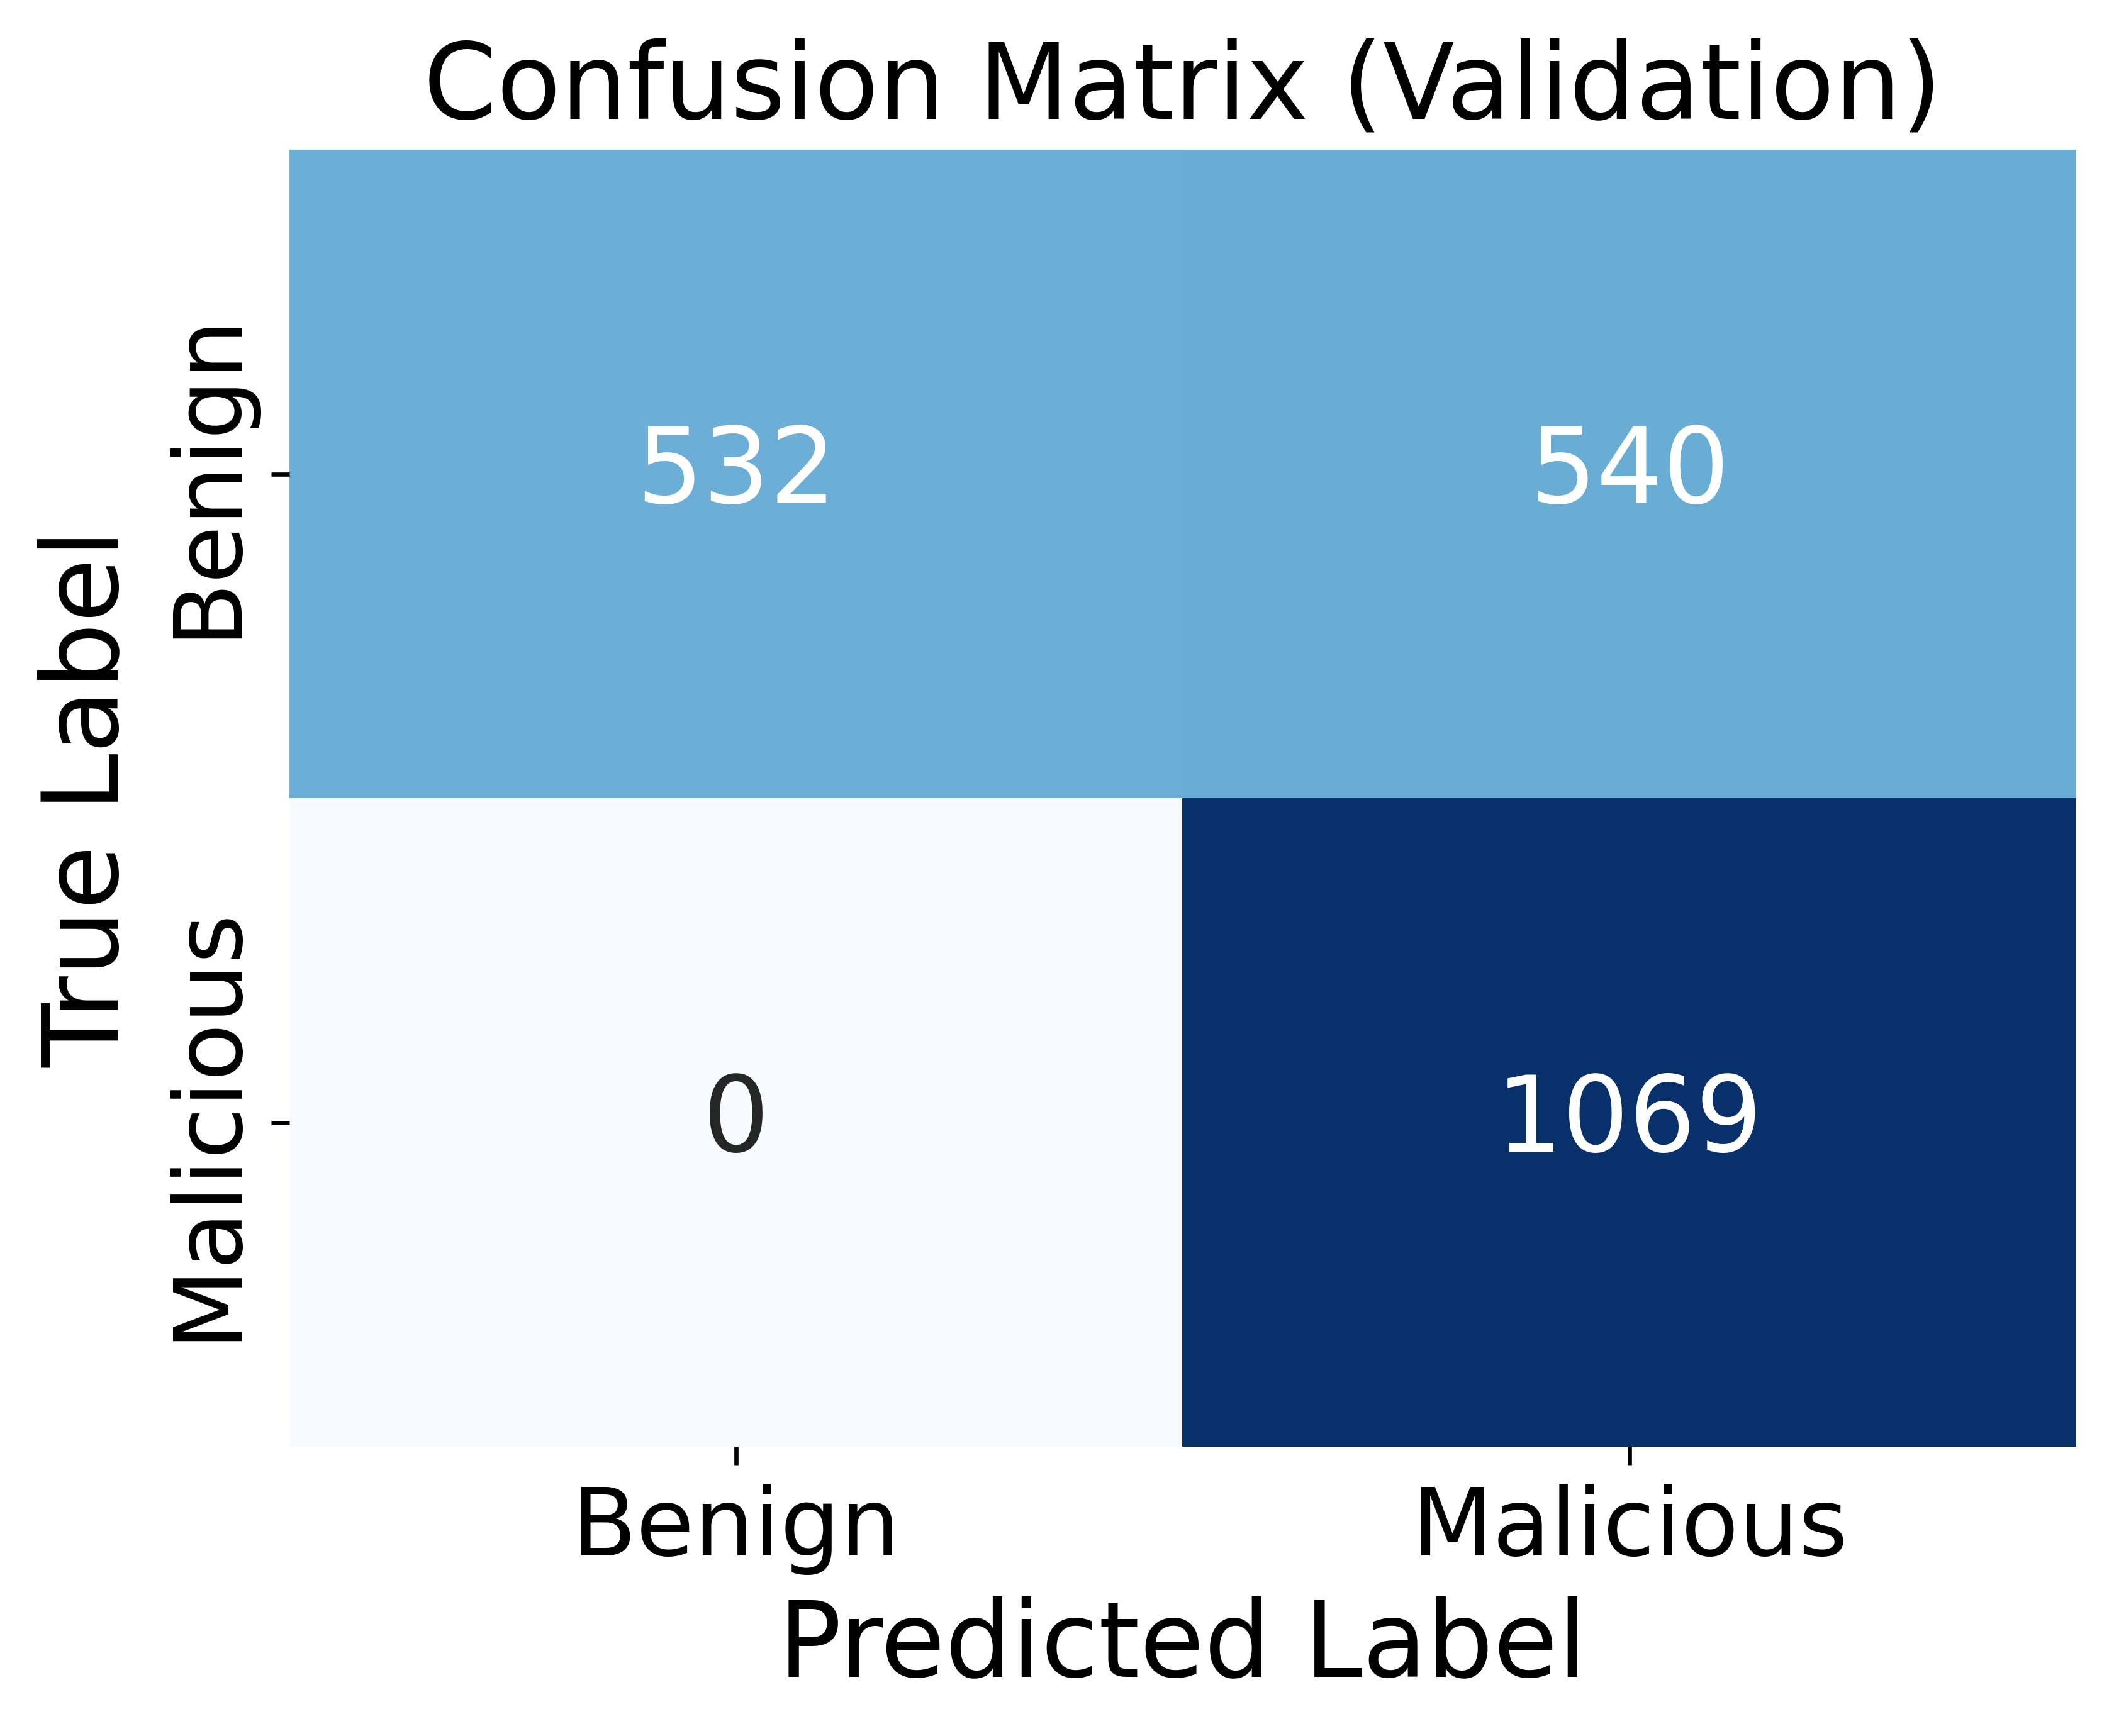

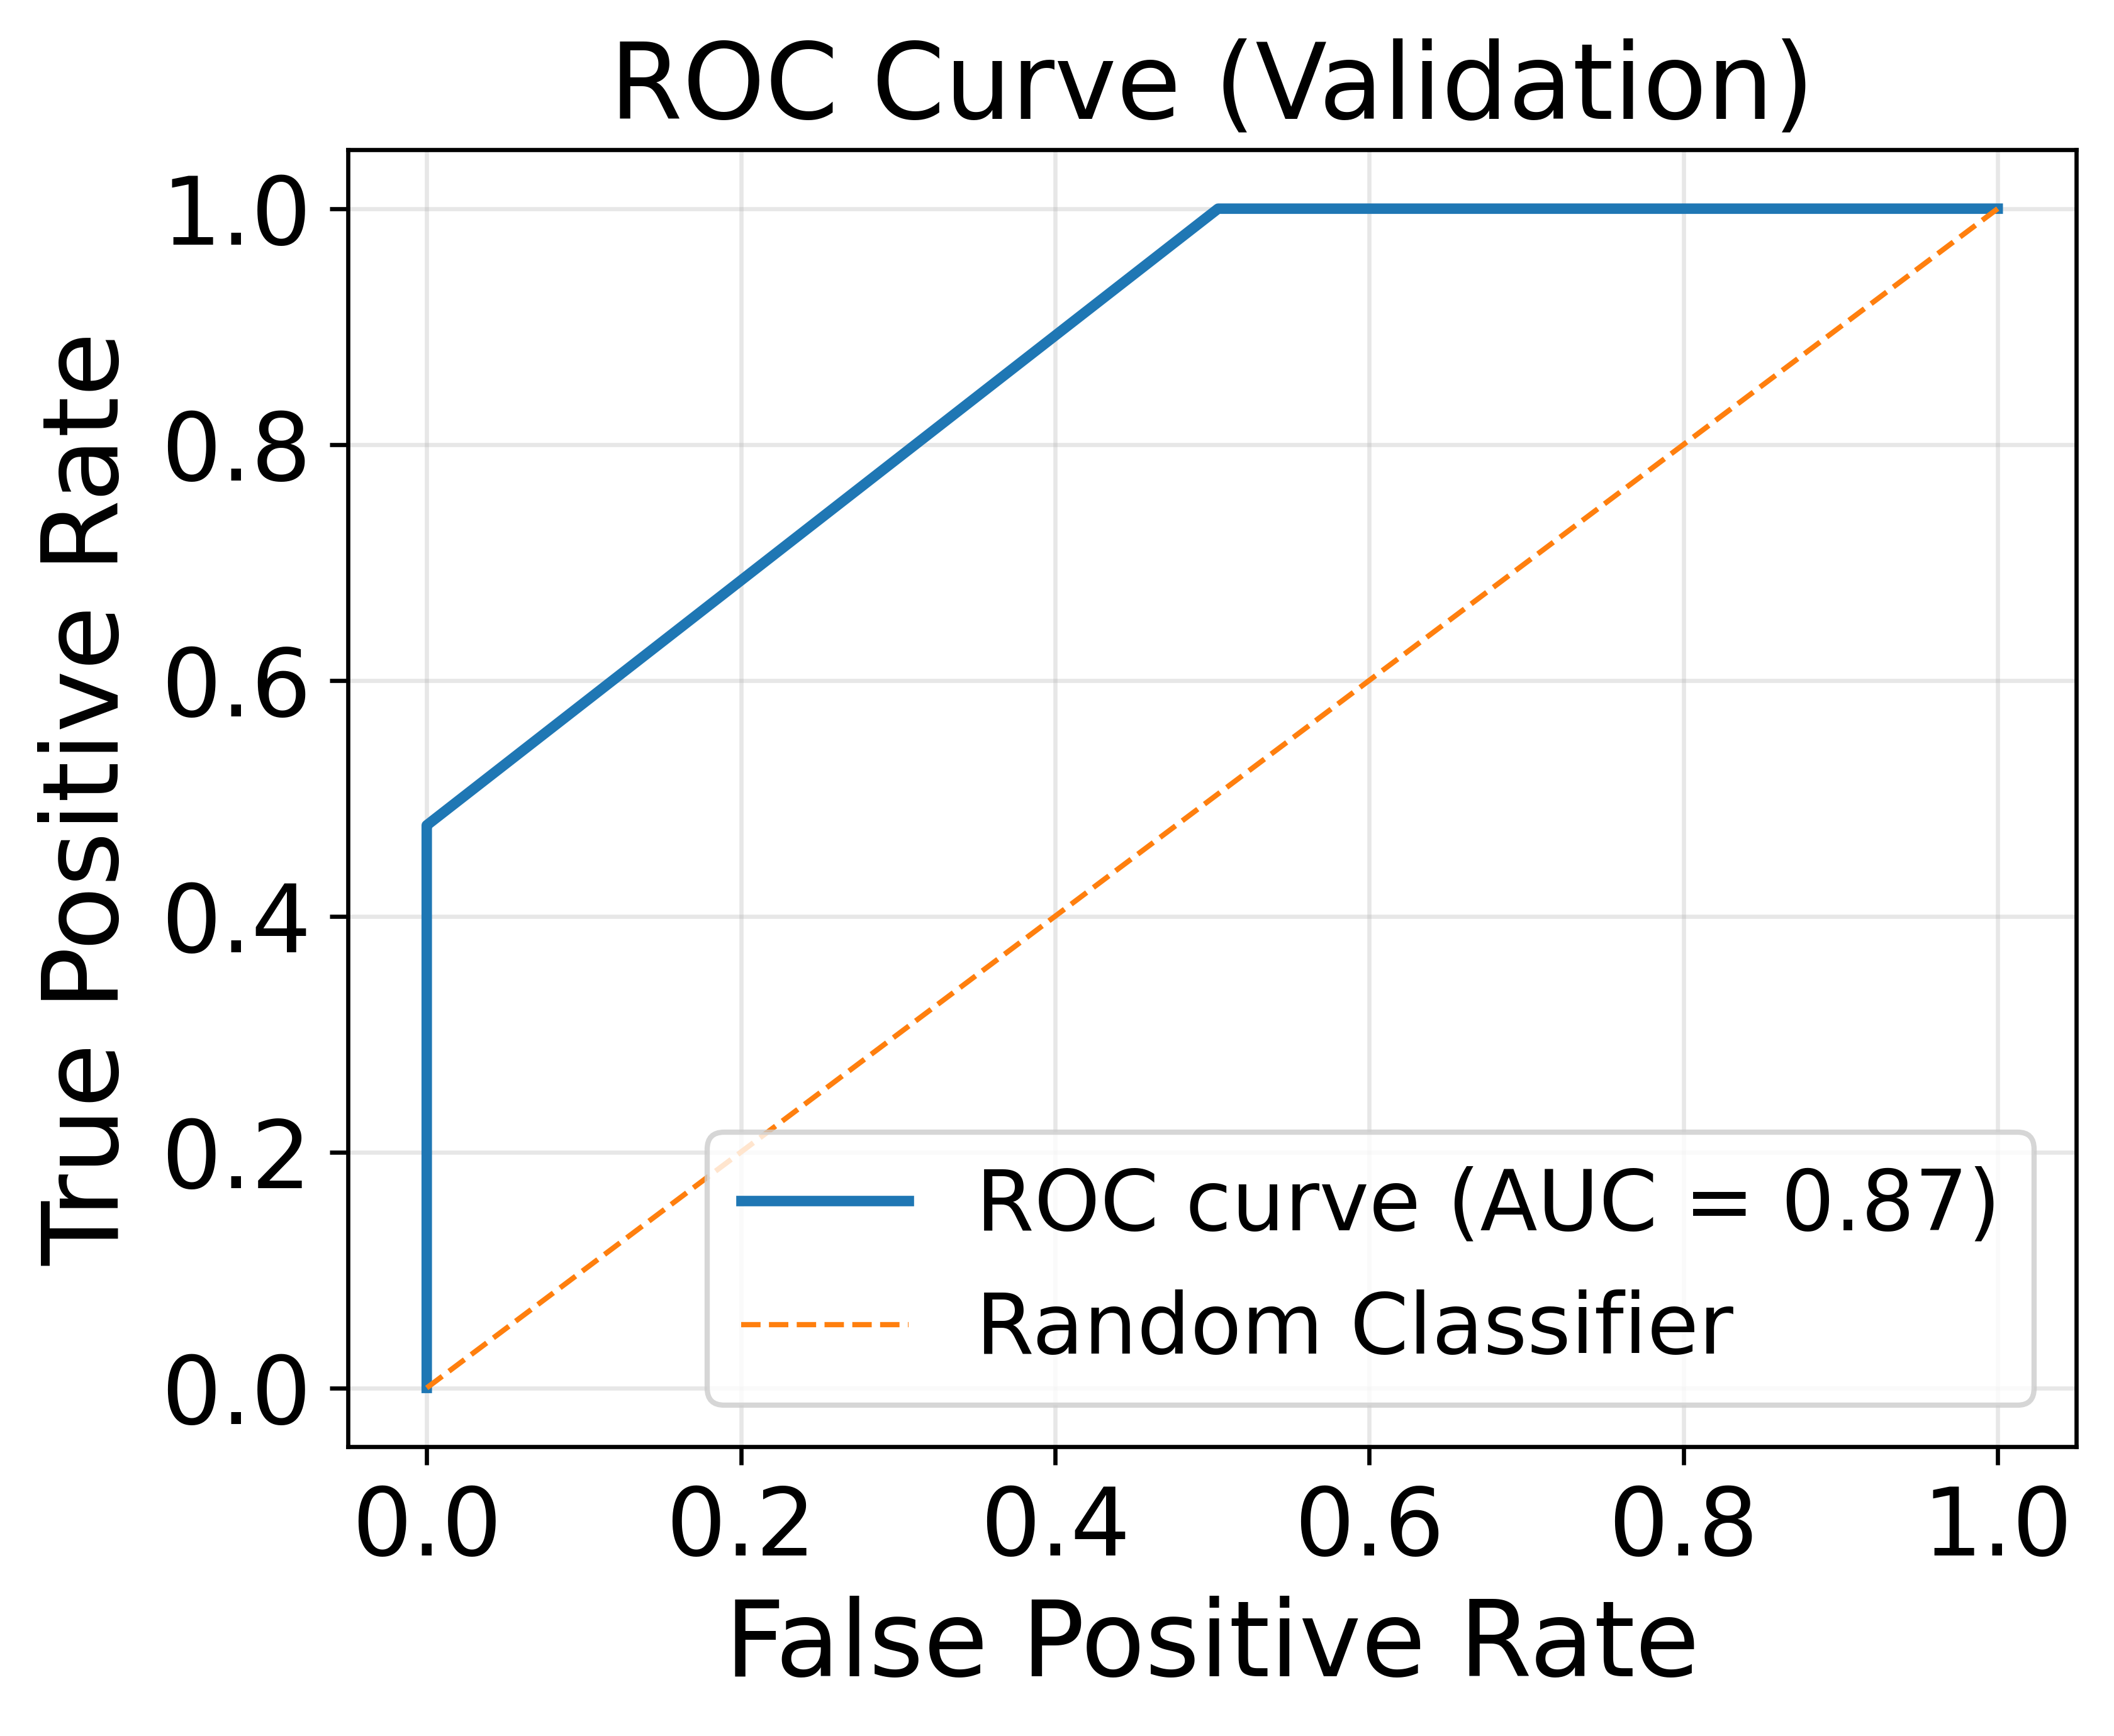


Evaluation Results: Test
Accuracy  : 0.757123
Precision : 0.672750
Recall    : 1.000000
F1-score  : 0.804364
ROC AUC   : 0.870876
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   1.000000  0.514925  0.679803      1072
         1.0   0.672750  1.000000  0.804364      1069

    accuracy                       0.757123      2141
   macro avg   0.836375  0.757463  0.742084      2141
weighted avg   0.836604  0.757123  0.741996      2141



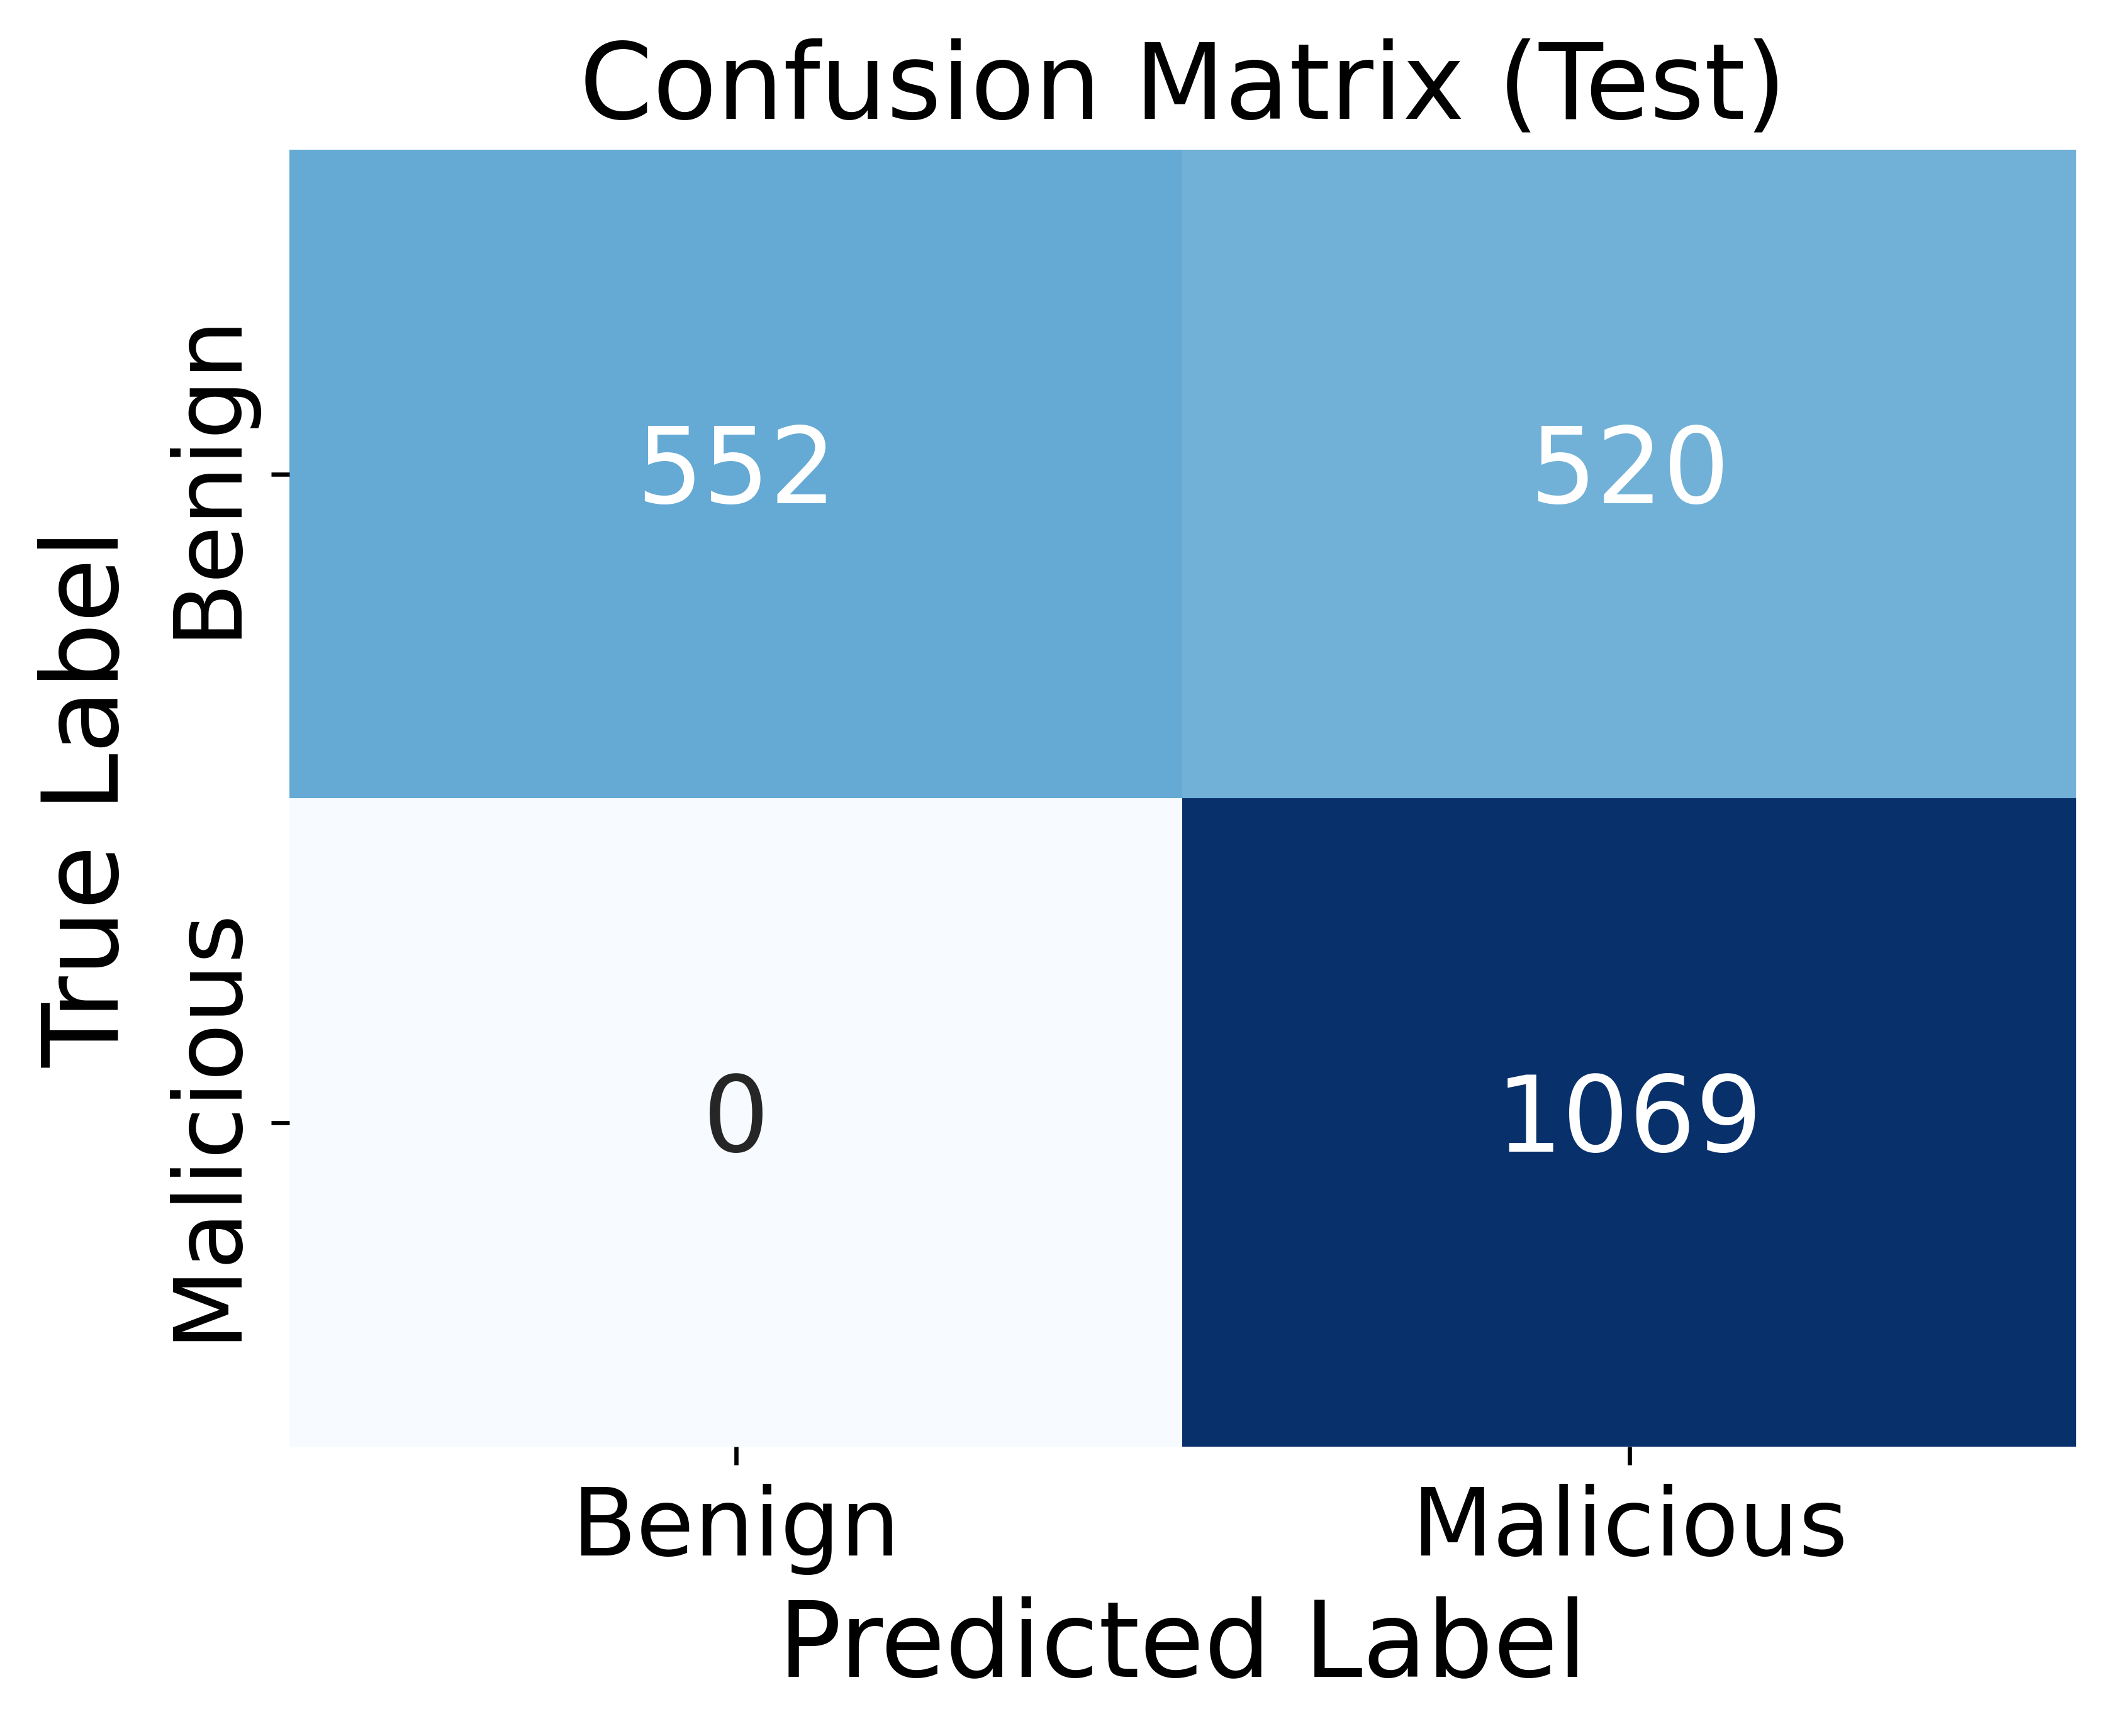

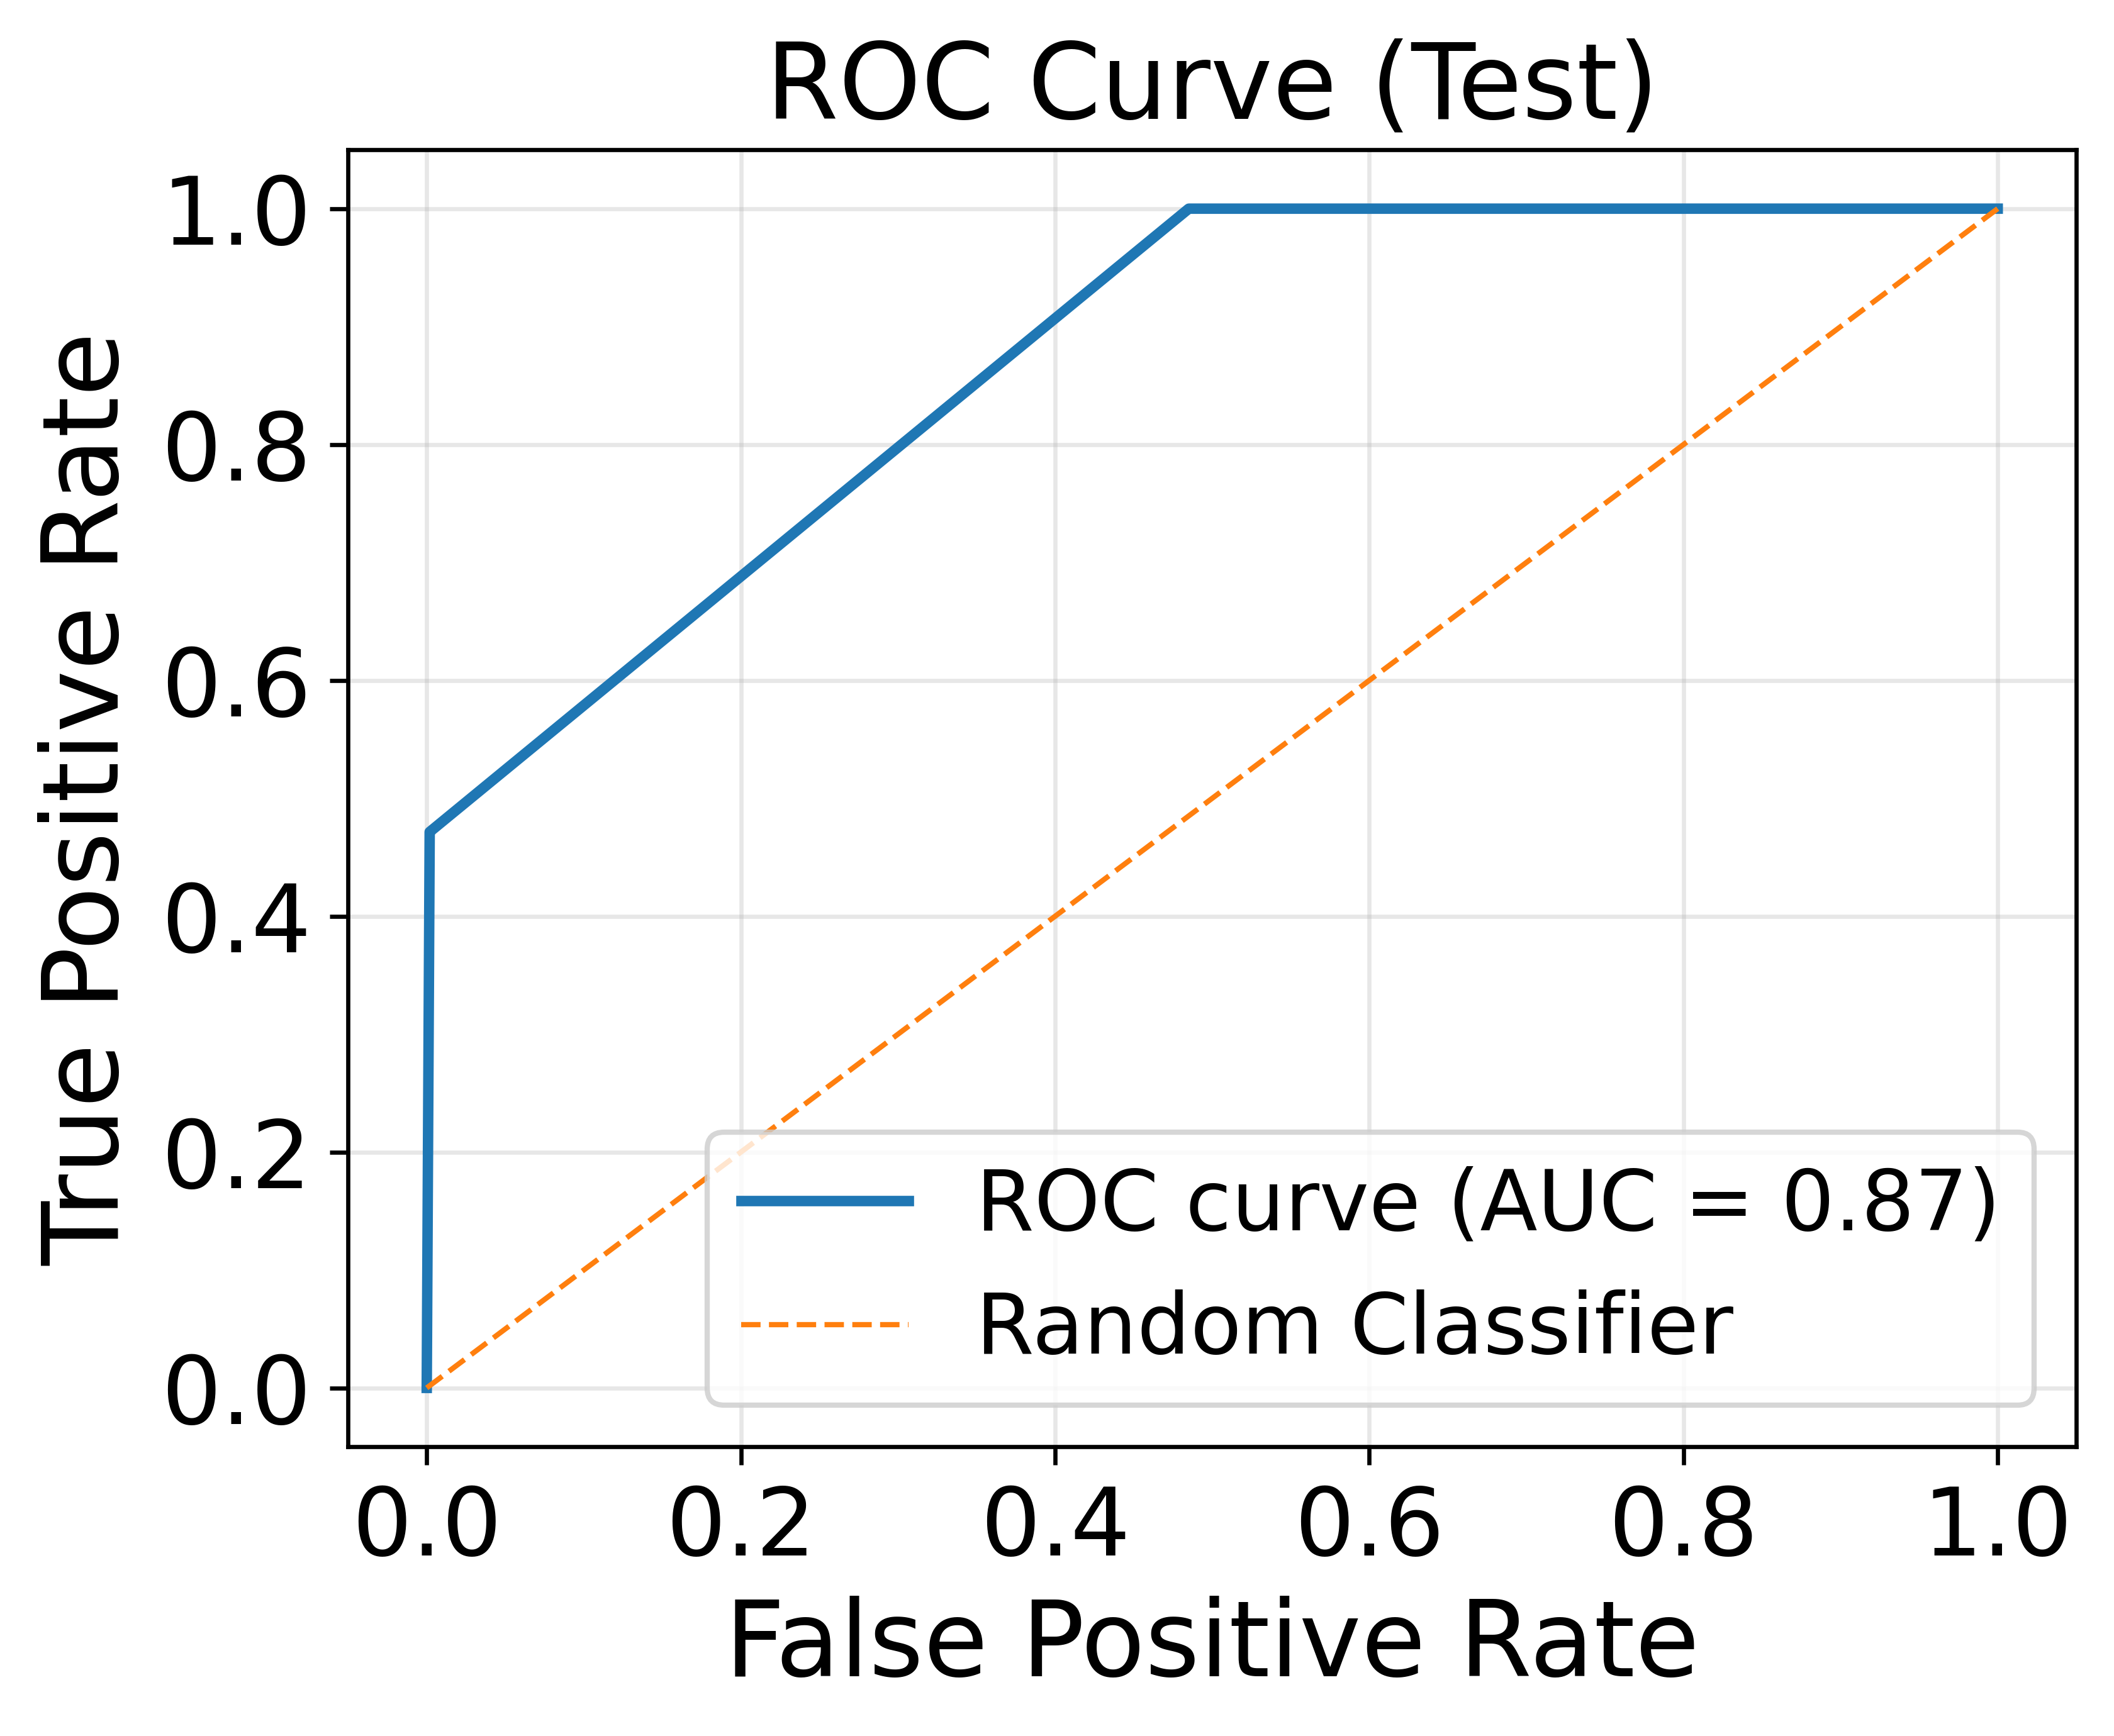

In [20]:
def evaluate_and_plot(model, encodings, X_num, y_true, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    encodings : dict or BatchEncoding
        Tokenized transformer inputs containing 'input_ids' and 'attention_mask'.
    X_num : np.ndarray or sparse matrix
        Additional numerical feature matrix.
    y_true : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Prepare model inputs
    # --------------------------------------------------------
    inputs = [
        np.array(encodings["input_ids"]),
        np.array(encodings["attention_mask"]),
        X_num
    ]

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(inputs, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Benign", "Malicious"],
        yticklabels=["Benign", "Malicious"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y_true),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, train_enc, X_train_num, y_train, "Train")
val_results   = evaluate_and_plot(model, val_enc, X_val_num, y_val, "Validation")
test_results  = evaluate_and_plot(model, test_enc, X_test_num, y_test, "Test")

### Save All Results

In [21]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Install_PSO_Attention_DistilGPT2\evaluation_summary.csv
Excel: Evaluation_Outputs_Install_PSO_Attention_DistilGPT2\evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.751326,0.667603,1.0,0.800674,0.868951
1,Validation,0.747781,0.664388,1.0,0.798357,0.868295
2,Test,0.757123,0.672750,1.0,0.804364,0.870876


### Clear Final Backend Session

In [22]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()